# Von Karman vortex street with FEniCSx + `solve_dae`

<a href="https://colab.research.google.com/github/SolveDAE/solve_dae/blob/main/examples/daes/von_karman_vortex_street.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook simulates the classical Karman vortex street: unsteady, incompressible
flow around a cylinder in a channel, following the DFG benchmark case 2D-2
(Reynolds number 100):

> Schaefer, M., Turek, S. (1996). *Benchmark computations of laminar flow around a
> cylinder*. In: Flow Simulation with High-Performance Computers II.
> https://doi.org/10.1007/978-3-322-89849-4_39

The incompressible Navier-Stokes equations are discretized in space with
[FEniCSx](https://fenicsproject.org/) (Taylor-Hood P2/P1 elements). Since the
incompressibility constraint `div(u) = 0` acts on the velocity only, the pressure
enters the semi-discrete equations in exactly the same way as a Lagrange multiplier
enters the equations of motion of a constrained mechanical system - and the resulting
velocity-pressure system is a DAE of **index 2**.

Following the index reduction used for constrained mechanical systems, the pressure is
replaced by the time derivative of a **pressure impulse** `Pi`,

$$p = \dot{\Pi} ,$$

which turns the problem into a **stabilized index-1** DAE `F(t, y, y') = 0` for
`y = (u, Pi)`:

$$
\begin{aligned}
  M \dot{u} - D^\mathrm{T} \dot{\Pi} + \mu K u + N(u) u &= 0 & &\text{(momentum)} \\
  D u &= 0 & &\text{(incompressibility)}
\end{aligned}
$$

The pressure block therefore appears in the mass form `am`, which multiplies `y'`, and
**not** in the residual form `F`. Three consequences:

* standard embedded error estimators and step-size controllers apply unchanged - no
  index-2 error scaling and no declaration of index-2 variables is required,
* the fluid at rest is a *consistent* initial state, so no pressure Poisson problem
  has to be solved for initialization; this uses the C2-continuous smoothstep ramp of
  the inflow (with a linear ramp, `y'(0) = 0` would be inconsistent). `Pi(0) = 0` is a
  pure gauge choice, since only `Pi'` enters the equations,
* the physical pressure is recovered from the returned derivatives as
  `p = sol.yp[pressure dofs]`, at no additional cost. Note that the *state* `(u, Pi)`
  carries the classical order `2s - 1`, whereas the derivatives - and hence the
  pressure - carry the stage order `q = s`; the step size is selected to control the
  error of the state.

The DAE is solved in time with [`solve_dae`](https://github.com/SolveDAE/solve_dae)'s
implicit Radau IIA collocation method, using exact Jacobians assembled by FEniCSx.

Running all cells below will:

1. install FEniCSx (via the [FEM on Colab](https://fem-on-colab.github.io/) project),
   `gmsh`, and `solve_dae`,
2. build the mesh, set up and solve the DAE,
3. report solver statistics and diagnostics (step sizes, discrete incompressibility,
   recovered pressure),
4. render an animated GIF of the velocity field and a ParaView-ready VTK time series,
5. zip everything up and offer it for download.

Runtime: a couple of minutes total, most of it spent on the one-time FEniCSx
install.

> **Note:** the residual is assembled into SciPy sparse matrices, so this notebook is
> serial (single MPI rank).


## 1. Install dependencies

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    try:
        import dolfinx
    except ImportError:
        !wget -nc "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh"
        !bash "/tmp/fenicsx-install.sh"

    # the gmsh PyPI wheel is linked against system OpenGL/X11 libraries (for
    # its GUI, which we never use here) that a stock Colab image does not
    # preinstall; without these, `import gmsh` fails with an OSError like
    # "libGLU.so.1: cannot open shared object file".
    !apt-get -qq update && apt-get -qq install -y libglu1-mesa libgl1 libxcursor1 libxinerama1 libxft2 libxrender1

    !pip install -q solve_dae gmsh
else:
    print("Not running on Google Colab -- make sure dolfinx, gmsh, and solve_dae "
          "are already installed in this environment.")


--2026-08-04 08:22:02--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-08-04 08:22:03 (43.0 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/e12a85f2/release

In [2]:
from importlib.metadata import version, PackageNotFoundError

import dolfinx
import gmsh
import solve_dae


def pkg_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "n/a (not pip-installed)"


print(f"dolfinx version:   {dolfinx.__version__}")
print(f"gmsh version:      {pkg_version('gmsh')}")
print(f"solve_dae version: {pkg_version('solve_dae')}")


dolfinx version:   0.11.0.post0
gmsh version:      4.15.2
solve_dae version: 0.2.4


## 2. Imports

In [3]:
import time
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc

import basix
import basix.ufl
import dolfinx.fem as dfem
import dolfinx.fem.petsc as dfem_petsc
import dolfinx.io.gmsh as dgmsh
from dolfinx.io import VTKFile
import ufl

from scipy.sparse import csr_matrix
from solve_dae.integrate import solve_dae

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.animation as animation
from IPython.display import HTML, display


## 3. Mesh generation

A channel with a circular obstacle, built with `gmsh`. Facet tags follow the DFG
benchmark convention: 1 = inflow (left), 2 = bottom wall, 3 = outflow (right),
4 = top wall, 5 = cylinder.


In [4]:
def dolfinx_to_scipy(A):
    """Convert an assembled PETSc matrix to a SciPy CSR matrix."""
    A_csr = A.getValuesCSR()
    return csr_matrix(A_csr[::-1], shape=A.getSize())


def create_mesh(characteristic_length, extends=(2.2, 0.41), center=(0.2, 0.2), radius=0.05):
    """Build a "channel with circular obstacle" mesh using gmsh."""
    gmsh.initialize()
    model = gmsh.model
    model.add("channel_with_cylinder")
    model.setCurrent("channel_with_cylinder")

    dim = 2
    channel = model.occ.addRectangle(0, 0, 0, *extends)
    disk = model.occ.addDisk(*center, 0, radius, radius)
    fluid = model.occ.cut([(dim, channel)], [(dim, disk)])
    model.occ.synchronize()

    volumes = model.getEntities(dim=dim)
    assert volumes == fluid[0]
    fluid_marker = 11
    model.addPhysicalGroup(volumes[0][0], [volumes[0][1]], fluid_marker)
    model.setPhysicalName(volumes[0][0], fluid_marker, "fluid")

    left_marker, bottom_marker, right_marker, top_marker, disk_marker = 1, 2, 3, 4, 5
    boundaries = [
        (left_marker, lambda x: np.isclose(x[0], 0)),
        (bottom_marker, lambda x: np.isclose(x[1], 0)),
        (right_marker, lambda x: np.isclose(x[0], extends[0])),
        (top_marker, lambda x: np.isclose(x[1], extends[1])),
    ]

    left, bottom, right, top = None, None, None, None
    disk_lines = []
    for line in model.getEntities(dim=dim - 1):
        com = model.occ.getCenterOfMass(line[0], line[1])
        for marker, locator in boundaries:
            if locator(com):
                if marker == left_marker:
                    left = line[1]
                elif marker == bottom_marker:
                    bottom = line[1]
                elif marker == right_marker:
                    right = line[1]
                elif marker == top_marker:
                    top = line[1]
                break
        else:
            # none of the straight boundaries matched -> part of the disk
            disk_lines.append(line[1])

    model.addPhysicalGroup(dim - 1, [left], left_marker, "left")
    model.addPhysicalGroup(dim - 1, [bottom], bottom_marker, "bottom")
    model.addPhysicalGroup(dim - 1, [right], right_marker, "right")
    model.addPhysicalGroup(dim - 1, [top], top_marker, "top")
    model.addPhysicalGroup(dim - 1, disk_lines, disk_marker, "disk")

    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", characteristic_length)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", characteristic_length)
    model.mesh.generate(dim=dim)

    mesh_data = dgmsh.model_to_mesh(model, MPI.COMM_WORLD, rank=0, gdim=dim)
    gmsh.finalize()

    markers = dict(left=left_marker, bottom=bottom_marker, right=right_marker,
                   top=top_marker, disk=disk_marker)
    return mesh_data, markers, extends


In [24]:
# physical parameters (DFG 2D-2 benchmark: mean inflow velocity 1, cylinder
# diameter 0.1, kinematic viscosity 1e-3 -> Reynolds number Re = 1 * 0.1 / 1e-3 = 100)
rho = 1.0
nu = 1.0e-3
Ubar = 1.5  # peak (centerline) inflow velocity

characteristic_length = 1.5e-2   # [m] gmsh target edge length
cylinder_radius = 0.05           # [m]

mesh_data, markers, extends = create_mesh(
    characteristic_length=characteristic_length, radius=cylinder_radius)
mesh = mesh_data.mesh
facet_tags = mesh_data.facet_tags
gdim = mesh.geometry.dim
print(f"mesh: {mesh.geometry.x.shape[0]} vertices")


mesh: 4899 vertices


## 4. Function spaces and DAE weak form

Taylor-Hood (P2/P1) element pair for velocity / pressure impulse. This pair is inf-sup
(LBB) stable, which is precisely the regularity condition of the resulting DAE: the
discrete pressure Schur complement `S = D M^-1 D^T` is invertible. (For an enclosed
flow, where the velocity is prescribed on the whole boundary, the pressure level would
have to be fixed separately; here the natural outflow condition takes care of it.)

The weak form is split into

* `am` - everything multiplying the time derivative `y' = (u', Pi')`, i.e. the velocity
  mass matrix **and the pressure gradient**, since `p = Pi'`,
* `F` - the remaining spatial operator (viscous and convective terms) together with the
  incompressibility constraint.

The pressure row of `am` is empty (there is no evolution equation for `Pi`), so the
leading matrix `B = dF/dy'` is singular: the problem is a DAE, not an ODE.


In [25]:
# Taylor-Hood element pair (P2 velocity, P1 pressure impulse)
k = 1
Pu = basix.ufl.element("Lagrange", mesh.basix_cell(), k + 1, shape=(gdim,))
Pp = basix.ufl.element("Lagrange", mesh.basix_cell(), k)
V = dfem.functionspace(mesh, basix.ufl.mixed_element([Pu, Pp]))

u, Pi = ufl.TrialFunctions(V)
v_u, v_p = ufl.TestFunctions(V)

w = dfem.Function(V)   # DAE state            y  = (u, Pi)
wp = dfem.Function(V)  # DAE state derivative y' = (u', Pi');  Pi' IS the pressure
u_h, Pi_h = ufl.split(w)

# Stabilized index-1 DAE (see the introduction): the pressure is replaced by the time
# derivative of the pressure impulse, p = d(Pi)/dt.  The pressure gradient therefore
# belongs to the mass form `am`, which multiplies y', and NOT to the residual form `F`.
# `am` has an empty pressure row (no evolution equation for Pi), which makes the
# leading matrix B = dF/dy' singular -- the problem is a DAE, not an ODE.
F = (
    nu * ufl.inner(ufl.grad(v_u), ufl.grad(u_h)) * ufl.dx
    + rho * ufl.inner(v_u, ufl.grad(u_h) * u_h) * ufl.dx
    + ufl.inner(v_p, ufl.div(u_h)) * ufl.dx
)
am = (
    ufl.inner(v_u, u) * ufl.dx
    - ufl.inner(ufl.div(v_u), Pi) * ufl.dx
)
J = ufl.derivative(F, w)


## 5. Boundary conditions

No-slip on the bottom/top walls and the cylinder, a ramped-up parabolic inflow
profile on the left, and a natural (do-nothing) outflow condition on the right.


In [26]:
V_u, _ = V.sub(0).collapse()
mesh.topology.create_connectivity(gdim - 1, gdim)

T_RAMP = 2.0  # [s] duration of the inflow ramp

bcs = []

# no-slip: bottom wall, top wall, cylinder
wall_velocity = dfem.Function(V_u)
wall_velocity.x.array[:] = 0.0
for tag in (markers["bottom"], markers["top"], markers["disk"]):
    fcts = facet_tags.find(tag)
    dofs = dfem.locate_dofs_topological((V.sub(0), V_u), gdim - 1, fcts)
    bcs.append(dfem.dirichletbc(wall_velocity, dofs, V.sub(0)))


def smoothstep(x, x_min=0.0, x_max=1.0):
    """C2 smoothstep, used to ramp up the inflow velocity from rest."""
    x = np.clip((x - x_min) / (x_max - x_min), 0.0, 1.0)
    return 6 * x**5 - 15 * x**4 + 10 * x**3


def ramp(t):
    return smoothstep(t, 0.0, T_RAMP)


def inflow_profile(x, t):
    fy = 4.0 * x[1] * (extends[1] - x[1]) / extends[1] ** 2
    return np.stack((Ubar * ramp(t) * fy, np.zeros(x.shape[1])))


inflow_velocity = dfem.Function(V_u)
inflow_velocity.interpolate(lambda x: inflow_profile(x, 0.0))
fcts = facet_tags.find(markers["left"])
dofs = dfem.locate_dofs_topological((V.sub(0), V_u), gdim - 1, fcts)
bcs.append(dfem.dirichletbc(inflow_velocity, dofs, V.sub(0)))
# outflow (right boundary): natural (do-nothing) condition, no BC needed.

# ----------------------------------------------------------------------------
# Dirichlet conditions in RESIDUAL form.
#
# In a residual F(t, y, y') = 0 the prescribed velocities are imposed by *algebraic*
# rows,
#           r_i = y_i - u_D,i(t) = 0 ,
# i.e. those rows must not contain any time derivative (the corresponding rows of
# dF/dy' are zeroed in the assembly cell below).  The dofs stay unknowns of the DAE,
# which is why no lifting of the time derivative of the boundary data is needed: the
# solver determines u_D' itself by differentiating the algebraic row.
#
# NOTE: the `apply_lifting`/`set_bc(..., x0=w)` pattern must NOT be used here -- it
# builds the right-hand side of a Newton system for the *increment* du.  Inside a
# residual it would enforce  u' + u = u_D(t)  (a relaxation with unit time constant)
# instead of  u = u_D(t).
# ----------------------------------------------------------------------------
# unrolled dof indices in the mixed space that are constrained
bc_rows = np.unique(np.concatenate([bc.dof_indices()[0] for bc in bcs]))

g_bc = dfem.Function(V)  # scratch vector holding the prescribed values


def _write_prescribed_values(array):
    """Write the Dirichlet values of `bcs` into `array` (mixed-space numbering)."""
    for bc in bcs:
        try:
            bc.set(array)                    # dolfinx >= 0.8
        except AttributeError:               # older dolfinx
            dfem.set_bc(array, [bc])


# The boundary data is separable in time: the walls are at rest and the inflow is
# `ramp(t)` times a fixed profile, hence  u_D(t) = ramp(t) * u_D_ref  exactly.  The
# reference vector is interpolated ONCE here, so that evaluating the boundary data
# during the time integration is a single scalar multiplication.  (Interpolating the
# profile inside the residual would run a finite element interpolation over the whole
# velocity space on every one of the ~10^5 residual evaluations.)
inflow_velocity.interpolate(lambda x: inflow_profile(x, T_RAMP))  # ramp(T_RAMP) = 1
g_bc.x.array[:] = 0.0
_write_prescribed_values(g_bc.x.array)
u_D_ref = g_bc.x.array.copy()
u_D_ref_bc = u_D_ref[bc_rows]

# verify separability against the interpolation-based evaluation
for t_check in (0.37, 1.5, 7.0):
    inflow_velocity.interpolate(lambda x: inflow_profile(x, t_check))
    g_bc.x.array[:] = 0.0
    _write_prescribed_values(g_bc.x.array)
    assert np.allclose(g_bc.x.array, ramp(t_check) * u_D_ref, atol=1e-12), \
        "boundary data is not separable -- use the interpolation in fun_dae instead"
assert np.allclose(ramp(0.0) * u_D_ref, 0.0), "flow should start from rest"
assert 0.9 * Ubar < u_D_ref.max() <= Ubar + 1e-12, \
    f"unexpected prescribed values: {u_D_ref.max()}"
print(f"{bc_rows.size} of {u_D_ref.size} dofs are constrained; "
      f"peak inflow {u_D_ref.max():.3f} m/s")


1374 of 43349 dofs are constrained; peak inflow 1.500 m/s


## 6. Assembly: residual and Jacobian for `solve_dae`

`solve_dae` needs the residual `F(t, y, y')` and both Jacobians `dF/dy` and `dF/dy'`,
which is exactly what FEniCSx assembles (in sparse format):

* `dF/dy'` is the constant matrix `B` from the mass form `am`, with the rows of the
  prescribed velocities zeroed,
* `dF/dy` is the Jacobian of the spatial operator, with those rows replaced by the
  identity (the derivative of the algebraic row `y_i - u_D,i(t)`).


In [27]:
form_am = dfem.form(am)
residual_form = dfem.form(F)
jacobian_form = dfem.form(J)

M = dfem_petsc.create_matrix(form_am)
A = dfem_petsc.create_matrix(jacobian_form)

n_x = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
n_u = V_u.dofmap.index_map.size_global * V_u.dofmap.index_map_bs

# --- dF/dy' = B: constant and singular --------------------------------------
dfem_petsc.assemble_matrix(M, form_am)   # NOTE: no bcs
M.assemble()
B_scipy = dolfinx_to_scipy(M)

# Rows of B without a single entry carry no time derivative at all: these are exactly
# the algebraic equations of the DAE, i.e. the incompressibility constraint D u = 0.
# (Determining them from the structure of B avoids any assumption about the dof
# numbering of the mixed space.)
p_rows = np.flatnonzero(abs(B_scipy).max(axis=1).toarray().ravel() == 0.0)
assert p_rows.size == n_x - n_u, \
    f"expected {n_x - n_u} pressure rows, found {p_rows.size}"

# the rows of the prescribed velocities are algebraic too -> no time derivative
M_scipy = B_scipy.copy()
for _i in bc_rows:
    M_scipy.data[M_scipy.indptr[_i]:M_scipy.indptr[_i + 1]] = 0.0
M_scipy.eliminate_zeros()

# --- dF/dy: assemble once to freeze the sparsity pattern --------------------
dfem_petsc.assemble_matrix(A, jacobian_form)
A.assemble()
_indptr, _indices, _data = A.getValuesCSR()
Jy_scipy = csr_matrix((_data.copy(), _indices.copy(), _indptr.copy()), shape=A.getSize())

# positions in the data array that belong to the constrained rows, and the positions of
# their diagonal entries -- computed once, so that the row surgery below is a pair of
# numpy assignments instead of several sparse matrix copies per Jacobian evaluation
_bc_data = np.concatenate([np.arange(_indptr[_i], _indptr[_i + 1]) for _i in bc_rows])
_bc_diag = np.array([
    _indptr[_i] + np.searchsorted(_indices[_indptr[_i]:_indptr[_i + 1]], _i)
    for _i in bc_rows
])
assert np.array_equal(_indices[_bc_diag], bc_rows), \
    "diagonal entries of the constrained rows are missing from the sparsity pattern"
_pattern_checked = False

print(f"n_x = {n_x} (velocity {n_u}, pressure impulse {n_x - n_u}), "
      f"nnz(dF/dy) = {Jy_scipy.nnz}")


def fun_dae(t, y, yp):
    """Residual F(t, y, y') of the stabilized index-1 DAE."""
    w.x.array[:] = y
    wp.x.array[:] = yp

    L = dfem_petsc.assemble_vector(residual_form)
    L.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)

    r = M_scipy @ yp + L.array
    r[bc_rows] = y[bc_rows] - ramp(t) * u_D_ref_bc   # algebraic Dirichlet rows
    return r


def jac_dae(t, y, yp):
    """Jacobians (dF/dy, dF/dy') of the residual above.

    `Jy_scipy` and `M_scipy` are refilled in place and returned every time.  This is
    safe because the integrator only reads them (it forms `Jyp + h*MU*Jy`, which
    allocates a new matrix) and requests a new Jacobian before reusing it.
    """
    global _pattern_checked
    w.x.array[:] = y
    wp.x.array[:] = yp

    A.zeroEntries()
    dfem_petsc.assemble_matrix(A, jacobian_form)
    A.assemble()
    indptr, indices, data = A.getValuesCSR()
    if not _pattern_checked:  # the pattern is preallocated from the form; verify once
        assert np.array_equal(indptr, Jy_scipy.indptr), "sparsity pattern changed"
        assert np.array_equal(indices, Jy_scipy.indices), "sparsity pattern changed"
        _pattern_checked = True

    Jy_scipy.data[:] = data
    Jy_scipy.data[_bc_data] = 0.0    # clear the constrained rows ...
    Jy_scipy.data[_bc_diag] = 1.0    # ... and make them identity rows
    return Jy_scipy, M_scipy


n_x = 43349 (velocity 38450, pressure impulse 4899), nnz(dF/dy) = 1268707


### Diagnostic quantities

Two scalars are recorded during the integration, so that no state has to be stored:

* `||D u_n||`, the residual of the discrete incompressibility constraint. Its rows were
  identified above as the rows of `B = dF/dy'` that contain no entry at all.
* the pressure impulse and the recovered pressure, averaged over a small Gaussian
  window behind the cylinder. Using a window instead of a single degree of freedom
  keeps this independent of the dof numbering of the mixed space.


In [28]:
x_ufl = ufl.SpatialCoordinate(mesh)
x_probe, sigma_probe = (0.35, 0.2), 0.02
window = ufl.exp(
    -((x_ufl[0] - x_probe[0]) ** 2 + (x_ufl[1] - x_probe[1]) ** 2) / (2 * sigma_probe**2)
)
form_window = dfem.form(window * ufl.dx)
form_window_Pi = dfem.form(window * ufl.split(w)[1] * ufl.dx)
form_window_p = dfem.form(window * ufl.split(wp)[1] * ufl.dx)
window_area = dfem.assemble_scalar(form_window)
assert window_area > 0.0, "the probe window does not intersect the mesh"


def probe_values():
    """Mean pressure impulse and mean pressure near `x_probe` for the state in w, wp."""
    return (dfem.assemble_scalar(form_window_Pi) / window_area,
            dfem.assemble_scalar(form_window_p) / window_area)


print(f"probe window at {x_probe} with sigma = {sigma_probe} m")


probe window at (0.35, 0.2) with sigma = 0.02 m


## 7. Time integration

The fluid starts at rest. This is a consistent initial state for both `y` and `y'`: the
inflow is ramped up with a C2-continuous smoothstep, so the prescribed velocities *and*
their time derivatives vanish at `t = 0`, and `Pi(0) = 0` is a gauge choice.

`t_eval` is passed, so the solution is returned at the requested output times and
nothing else is stored: the local interpolant of each step is evaluated and then
discarded. (Without `t_eval`, or with `dense_output=True`, one interpolant per accepted
step is retained -- several GB for a problem of this size.)

Quantities that live at the *accepted steps* rather than at the output times -- the step
sizes and the constraint residual -- are collected by an `events` function. The solver
evaluates it once per accepted step; returning a constant means it never triggers, so it
does not influence the integration in any way.


In [29]:
t0, t1 = 0.0, 10.0
n_frames = 300
t_eval = np.linspace(t0, t1, n_frames)

# solver settings (kept in variables so that they end up in the exported statistics)
STAGES, RTOL, ATOL, FIRST_STEP = 3, 1e-4, 1e-4, 1e-3

w.x.array[:] = 0.0
wp.x.array[:] = 0.0
y0 = w.x.array.copy()
yp0 = wp.x.array.copy()

# the initial state must satisfy the residual (consistent initial conditions)
print(f"initial residual norm: {np.linalg.norm(fun_dae(t0, y0, yp0)):.3e}")

# --- per-step diagnostics ---------------------------------------------------
t_steps, div_norm, probes = [], [], []


def record_step(t, y, yp):
    """Evaluated once per accepted step (and once at t0) by the event machinery.

    Returns a constant, so no event is ever detected and the integration is unaffected;
    this is only a hook that gives access to the accepted steps while still using the
    plain `solve_dae` interface. Costs one extra residual evaluation per step.
    """
    residual = fun_dae(t, y, yp)   # also scatters y, yp into w and wp
    t_steps.append(t)
    div_norm.append(np.linalg.norm(residual[p_rows]))
    probes.append(probe_values())
    return 1.0


start = time.time()
sol = solve_dae(
    fun_dae, (t0, t1), y0, yp0,
    jac=jac_dae,
    method="Radau",
    stages=STAGES,
    rtol=RTOL,
    atol=ATOL,
    first_step=FIRST_STEP,
    t_eval=t_eval,
    events=record_step,
)
elapsed = time.time() - start
assert sol.success, sol.message

t_steps = np.array(t_steps)
div_norm = np.array(div_norm)
probes = np.array(probes)
h = np.diff(t_steps)
assert t_steps.size == sol.naccpt + 1, "the event hook did not fire once per step"

# Output frames. `sol.y` is exact at t = t0, but `sol.yp` there is extrapolated from the
# interpolant of the first (tiny) step and therefore only stage-order accurate; the
# consistent initial derivative is known exactly, so it is used instead.
t_out, y_out, yp_out = sol.t, sol.y, sol.yp
if np.isclose(t_out[0], t0):
    y_out[:, 0], yp_out[:, 0] = y0, yp0

print(f"elapsed time:      {elapsed:.2f} s")
print(f"cells:             {mesh.topology.index_map(gdim).size_global}")
print(f"unknowns:          n_x = {n_x} (velocity {n_u}, pressure impulse {n_x - n_u})")
print(f"steps:             {sol.naccpt} accepted, {sol.nrejct} rejected")
print(f"nfev / njev / nlu: {sol.nfev} / {sol.njev} / {sol.nlu}"
      f"   (nlusolve {sol.nlusolve})")
print(f"                   plus {t_steps.size} residual evaluations for the "
      f"diagnostics, which the solver does not count")
print(f"step size:         mean {h.mean():.3e}, min {h.min():.3e}, max {h.max():.3e}")
print(f"max ||D u_n||:     {div_norm.max():.3e}")


initial residual norm: 0.000e+00
elapsed time:      1452.18 s
cells:             9427
unknowns:          n_x = 43349 (velocity 38450, pressure impulse 4899)
steps:             301 accepted, 3 rejected
nfev / njev / nlu: 5002 / 294 / 612   (nlusolve 3435)
                   plus 302 residual evaluations for the diagnostics, which the solver does not count
step size:         mean 3.322e-02, min 1.000e-03, max 2.190e-01
max ||D u_n||:     7.540e-17


## 8. Diagnostics: step sizes, incompressibility, recovered pressure

Three quantities, all recorded at the **accepted steps**:

* the step sizes chosen by the **unmodified** adaptive controller - no index-2 error
  scaling is used anywhere,
* the discrete incompressibility `||D u_n||`, which vanishes up to the accuracy of the
  simplified Newton iterations because the Radau IIA methods are stiffly accurate,
* the pressure impulse `Pi` and the recovered pressure `p = Pi'` behind the cylinder.

The distinction between accepted steps and interpolated output matters: the algebraic
equations (incompressibility and the prescribed velocities) hold at the grid points up
to the Newton tolerance, but only up to the interpolation error in between - and the
animation and the VTK export below use interpolated values.


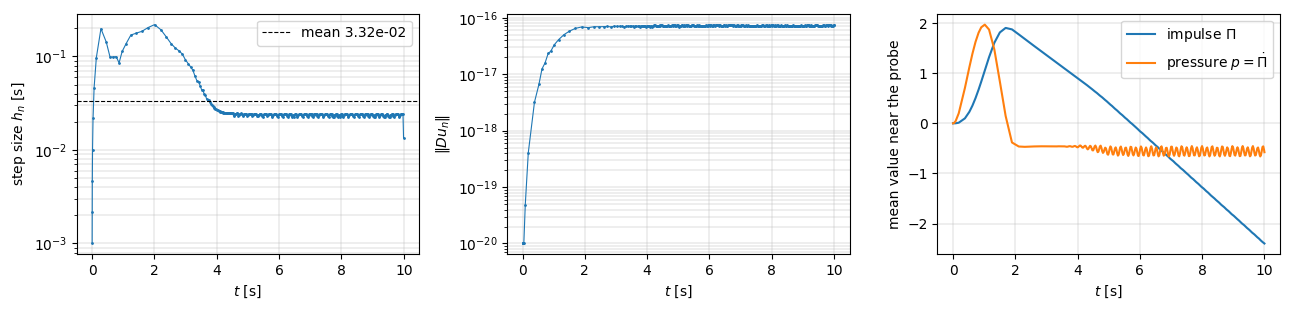

--- numbers for Example 6.7 (paste into header/commands.tex) ---
\newcommand{\SIkarmanNX}{43349}
\newcommand{\SIkarmanSTEPS}{301}
\newcommand{\SIkarmanNFEV}{5002}
\newcommand{\SIkarmanNLU}{612}
\newcommand{\SIkarmanHBAR}{3.32e-02}


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

axes[0].semilogy(0.5 * (t_steps[1:] + t_steps[:-1]), h, ".-", lw=0.8, ms=2)
axes[0].axhline(h.mean(), color="k", ls="--", lw=0.8, label=f"mean {h.mean():.2e}")
axes[0].set_xlabel("$t$ [s]")
axes[0].set_ylabel("step size $h_n$ [s]")
axes[0].legend()

axes[1].semilogy(t_steps, np.maximum(div_norm, 1e-20), ".-", lw=0.8, ms=2)
axes[1].set_xlabel("$t$ [s]")
axes[1].set_ylabel(r"$\|D u_n\|$")

axes[2].plot(t_steps, probes[:, 0], label=r"impulse $\Pi$")
axes[2].plot(t_steps, probes[:, 1], label=r"pressure $p = \dot{\Pi}$")
axes[2].set_xlabel("$t$ [s]")
axes[2].set_ylabel("mean value near the probe")
axes[2].legend()

for ax in axes:
    ax.grid(True, which="both", lw=0.3)
fig.tight_layout()
fig.savefig("karman_statistics.pdf")
fig.savefig("karman_statistics.png", dpi=150)
plt.show()

print("--- numbers for Example 6.7 (paste into header/commands.tex) ---")
print(f"\\newcommand{{\\SIkarmanNX}}{{{n_x}}}")
print(f"\\newcommand{{\\SIkarmanSTEPS}}{{{sol.naccpt}}}")
print(f"\\newcommand{{\\SIkarmanNFEV}}{{{sol.nfev}}}")
print(f"\\newcommand{{\\SIkarmanNLU}}{{{sol.nlu}}}")
print(f"\\newcommand{{\\SIkarmanHBAR}}{{{h.mean():.2e}}}")


### Export of the reportable quantities

Everything that goes into the paper is written to disk, so that no number has to be
copied by hand:

| file | contents |
|---|---|
| `karman_steps.csv` | one row per accepted step: `t_begin`, `t_end`, `t_mid`, `h` |
| `karman_diagnostics.csv` | one row per grid point: `t`, `div_norm`, `Pi_probe`, `p_probe` |
| `karman_statistics.csv` | problem size, solver settings and work counters |
| `karman_macros.tex` | `\renewcommand` definitions for the `\SIkarman*` placeholders |

The two time series are kept in separate files because they live on different point
sets: a step size belongs to an *interval* (`t_begin` to `t_end`, plot it against
`t_mid`), whereas the constraint residual and the probe values are evaluated *at* the
grid points, of which there is one more. Both are indexed by `t`, so joining them is
trivial if you prefer one table. `pgfplots` selects columns by name, e.g.

```latex
\addplot table[x=t_mid, y=h, col sep=comma] {karman_steps.csv};
```


In [31]:
import csv

# --- per-step quantities: one row per accepted step -------------------------
steps = np.column_stack((t_steps[:-1], t_steps[1:],
                         0.5 * (t_steps[:-1] + t_steps[1:]), h))
np.savetxt("karman_steps.csv", steps, delimiter=",", fmt="%.12e",
           comments="", header="t_begin,t_end,t_mid,h")

# --- diagnostics: one row per grid point ------------------------------------
diagnostics = np.column_stack((t_steps, div_norm, probes[:, 0], probes[:, 1]))
np.savetxt("karman_diagnostics.csv", diagnostics, delimiter=",", fmt="%.12e",
           comments="", header="t,div_norm,Pi_probe,p_probe")

# --- solver statistics and problem data -------------------------------------
n_cells = mesh.topology.index_map(gdim).size_global
statistics = [
    ("characteristic_length", characteristic_length, "m", "gmsh target edge length"),
    ("cells", n_cells, "-", "number of triangles"),
    ("n_x", n_x, "-", "number of unknowns"),
    ("n_u", n_u, "-", "velocity unknowns (P2)"),
    ("n_Pi", n_x - n_u, "-", "pressure impulse unknowns (P1)"),
    ("rho", rho, "kg/m^3", "density"),
    ("nu", nu, "m^2/s", "kinematic viscosity"),
    ("Ubar", Ubar, "m/s", "peak inflow velocity"),
    ("Re", (Ubar / 1.5) * 2 * cylinder_radius / nu, "-", "Reynolds number"),
    ("t_ramp", T_RAMP, "s", "duration of the inflow ramp"),
    ("t0", t0, "s", "initial time"),
    ("t1", t1, "s", "final time"),
    ("stages", STAGES, "-", "number of Radau IIA stages"),
    ("order", 2 * STAGES - 1, "-", "classical order of the method"),
    ("rtol", RTOL, "-", "relative tolerance"),
    ("atol", ATOL, "-", "absolute tolerance"),
    ("first_step", FIRST_STEP, "s", "initial step size"),
    ("steps_accepted", sol.naccpt, "-", "accepted steps"),
    ("steps_rejected", sol.nrejct, "-", "rejected steps"),
    ("nfev", sol.nfev, "-", "residual evaluations (excluding the diagnostics)"),
    ("njev", sol.njev, "-", "Jacobian evaluations"),
    ("nlu", sol.nlu, "-", "LU decompositions of the iteration matrix"),
    ("nlusolve", sol.nlusolve, "-", "forward/backward substitutions"),
    ("nfev_diagnostics", t_steps.size, "-", "extra residuals for the diagnostics"),
    ("h_mean", h.mean(), "s", "mean accepted step size"),
    ("h_min", h.min(), "s", "smallest accepted step size"),
    ("h_max", h.max(), "s", "largest accepted step size"),
    ("div_max", div_norm.max(), "-", "max ||D u_n|| at the grid points"),
    ("elapsed", elapsed, "s", "wall-clock time of the integration"),
]
with open("karman_statistics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(("quantity", "value", "unit", "description"))
    for name, value, unit, description in statistics:
        assert "," not in description
        writer.writerow((name, f"{value:.12g}", unit, description))

# --- LaTeX macros for the manuscript ----------------------------------------
# The snapshot of Figure 1 was rendered from one of the output frames; set the index to
# the frame actually shown (the file name Karman0100.png suggests frame 100).
I_SNAPSHOT = 100
t_snapshot = t_out[I_SNAPSHOT]


def latex_float(value, digits=2):
    r"""Format a float as a LaTeX expression, e.g. 2.34 \cdot 10^{-3}."""
    mantissa, exponent = f"{value:.{digits}e}".split("e")
    exponent = int(exponent)
    if exponent == 0:
        return mantissa
    return rf"{mantissa} \cdot 10^{{{exponent}}}"


macros = {
    "SIkarmanNX": f"{n_x}",
    "SIkarmanTIME": rf"{t_snapshot:.2f}\,\mathrm{{s}}",
    "SIkarmanSTEPS": f"{sol.naccpt}",
    "SIkarmanNFEV": f"{sol.nfev}",
    "SIkarmanNLU": f"{sol.nlu}",
    "SIkarmanHBAR": rf"{latex_float(h.mean())}\,\mathrm{{s}}",
}
with open("karman_macros.tex", "w") as f:
    f.write("% Generated by von_karman_vortex_street.ipynb -- do not edit by hand.\n")
    f.write(f"% {n_cells} cells, n_x = {n_x}, atol = rtol = {RTOL:g}, "
            f"{sol.naccpt} accepted steps\n")
    for name, value in macros.items():
        f.write(f"\\renewcommand{{\\{name}}}{{{value}}}\n")

print("wrote karman_steps.csv        ", steps.shape[0], "rows")
print("wrote karman_diagnostics.csv ", diagnostics.shape[0], "rows")
print("wrote karman_statistics.csv  ", len(statistics), "entries")
print("wrote karman_macros.tex")
print()
print(open("karman_macros.tex").read(), end="")
print()
print("first rows of karman_steps.csv:")
print("".join(open("karman_steps.csv").readlines()[:4]), end="")


wrote karman_steps.csv         301 rows
wrote karman_diagnostics.csv  302 rows
wrote karman_statistics.csv   29 entries
wrote karman_macros.tex

% Generated by von_karman_vortex_street.ipynb -- do not edit by hand.
% 9427 cells, n_x = 43349, atol = rtol = 0.0001, 301 accepted steps
\renewcommand{\SIkarmanNX}{43349}
\renewcommand{\SIkarmanTIME}{3.34\,\mathrm{s}}
\renewcommand{\SIkarmanSTEPS}{301}
\renewcommand{\SIkarmanNFEV}{5002}
\renewcommand{\SIkarmanNLU}{612}
\renewcommand{\SIkarmanHBAR}{3.32 \cdot 10^{-2}\,\mathrm{s}}

first rows of karman_steps.csv:
t_begin,t_end,t_mid,h
0.000000000000e+00,1.000000000000e-03,5.000000000000e-04,1.000000000000e-03
1.000000000000e-03,3.166042216199e-03,2.083021108100e-03,2.166042216199e-03
3.166042216199e-03,7.851576512088e-03,5.508809364144e-03,4.685534295889e-03


### Optional: where does the time go?

Multiply the per-call timings by the counters above (`nfev`, `njev`, `nlu`) to see what
dominates. For a problem of this size the factorizations usually do; if `jac_dae` is
much more expensive than the finite element assembly inside it, the row surgery is the
culprit, and if `fun_dae` is, it is the assembly or the boundary data.


In [32]:
from scipy.sparse.linalg import splu

y_ref, yp_ref = y_out[:, -1].copy(), yp_out[:, -1].copy()


def _timeit(f, n=5):
    f()
    t = time.perf_counter()
    for _ in range(n):
        f()
    return (time.perf_counter() - t) / n * 1e3  # [ms]


t_fun = _timeit(lambda: fun_dae(t1, y_ref, yp_ref))
t_vec = _timeit(lambda: dfem_petsc.assemble_vector(residual_form))
t_jac = _timeit(lambda: jac_dae(t1, y_ref, yp_ref))
t_mat = _timeit(lambda: (A.zeroEntries(),
                         dfem_petsc.assemble_matrix(A, jacobian_form),
                         A.assemble()))
Jy, Jyp = jac_dae(t1, y_ref, yp_ref)
# stand-in for Radau's iteration matrix Jy + (c/h) Jyp (same sparsity, so the
# factorization cost is representative)
t_lu = _timeit(lambda: splu((Jy + (3.6 / h.mean()) * Jyp).tocsc()), n=3)

print(f"fun_dae                     {t_fun:8.2f} ms  x {sol.nfev:6d}"
      f"  = {t_fun * sol.nfev / 1e3:8.1f} s")
print(f"  of which FE assembly      {t_vec:8.2f} ms")
print(f"jac_dae                     {t_jac:8.2f} ms  x {sol.njev:6d}"
      f"  = {t_jac * sol.njev / 1e3:8.1f} s")
print(f"  of which FE assembly      {t_mat:8.2f} ms")
print(f"LU factorization            {t_lu:8.2f} ms  x {sol.nlu:6d}"
      f"  = {t_lu * sol.nlu / 1e3:8.1f} s")
print(f"total measured                                    "
      f"  = {(t_fun * sol.nfev + t_jac * sol.njev + t_lu * sol.nlu) / 1e3:8.1f} s"
      f"   (actual {elapsed:.1f} s)")


fun_dae                         5.87 ms  x   5002  =     29.4 s
  of which FE assembly          4.48 ms
jac_dae                        90.27 ms  x    294  =     26.5 s
  of which FE assembly         83.94 ms
LU factorization              875.63 ms  x    612  =    535.9 s
total measured                                      =    591.8 s   (actual 1452.2 s)


## 9. VTK output (velocity, pressure, pressure impulse) for ParaView

Note which field comes from where: the velocity and the pressure impulse are components
of the state `y`, whereas the **physical pressure is a component of the derivative**
`y'`. Writing `w.sub(1)` as "pressure" would export the impulse instead.


In [33]:
u_out = w.sub(0).collapse()
p_out = wp.sub(1).collapse()
Pi_out = w.sub(1).collapse()
u_out.name, p_out.name, Pi_out.name = "u", "p", "Pi"

with (
    VTKFile(mesh.comm, "von_karman_vortex_street_vtk/u.pvd", "w") as vtk_u,
    VTKFile(mesh.comm, "von_karman_vortex_street_vtk/p.pvd", "w") as vtk_p,
    VTKFile(mesh.comm, "von_karman_vortex_street_vtk/Pi.pvd", "w") as vtk_Pi,
):
    for ti, yi, ypi in zip(t_out, y_out.T, yp_out.T):
        w.x.array[:] = yi
        wp.x.array[:] = ypi
        u_out.x.array[:] = w.sub(0).collapse().x.array
        p_out.x.array[:] = wp.sub(1).collapse().x.array   # physical pressure = d(Pi)/dt
        Pi_out.x.array[:] = w.sub(1).collapse().x.array   # pressure impulse
        vtk_u.write_function(u_out, ti)
        vtk_p.write_function(p_out, ti)
        vtk_Pi.write_function(Pi_out, ti)
print("Saved velocity, pressure and pressure-impulse time series to "
      "von_karman_vortex_street_vtk/")


Saved velocity, pressure and pressure-impulse time series to von_karman_vortex_street_vtk/


## 10. Animation: velocity magnitude over time

In [34]:
P1 = dfem.functionspace(mesh, ("Lagrange", 1))
speed_h = dfem.Function(P1)
speed_expr = dfem.Expression(ufl.sqrt(ufl.inner(u_h, u_h)), P1.element.interpolation_points)

coords = P1.tabulate_dof_coordinates()[:, :2]
triangles = mesh.topology.connectivity(gdim, 0).array.reshape(-1, 3)
triangulation = mtri.Triangulation(coords[:, 0], coords[:, 1], triangles)

fig, ax = plt.subplots(figsize=(8, 2))
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
title = ax.set_title("")
levels = np.linspace(0, 2.2 * Ubar, 31)


def update(frame):
    w.x.array[:] = y_out[:, frame]
    speed_h.interpolate(speed_expr)
    for coll in ax.collections:
        coll.remove()
    ax.tricontourf(triangulation, speed_h.x.array, levels=levels, cmap="viridis", extend="max")
    title.set_text(f"|u|,  t = {t_out[frame]:.2f} s")


ani = animation.FuncAnimation(fig, update, frames=len(t_out))
ani.save("von_karman_vortex_street.gif", writer=animation.PillowWriter(fps=20))
plt.close(fig)
print("Saved animation to von_karman_vortex_street.gif")


Saved animation to von_karman_vortex_street.gif


In [35]:
# display the animated GIF inline
display(HTML('<img src="von_karman_vortex_street.gif">'))


## 11. Download the results

In [36]:
import os
import shutil

archive_path = shutil.make_archive("von_karman_vortex_street_results", "zip",
                                    root_dir=".", base_dir="von_karman_vortex_street_vtk")
# also add the GIF to the archive
import zipfile
with zipfile.ZipFile(archive_path, "a") as zf:
    zf.write("von_karman_vortex_street.gif")
    for extra in ("karman_statistics.pdf", "karman_statistics.png",
                  "karman_steps.csv", "karman_diagnostics.csv",
                  "karman_statistics.csv", "karman_macros.tex"):
        if os.path.exists(extra):
            zf.write(extra)

print(f"Packaged results into {archive_path}")

if IN_COLAB:
    from google.colab import files
    files.download(archive_path)
else:
    print("Not running on Google Colab -- find the results at:")
    print(f"  {archive_path}")
    print("  von_karman_vortex_street.gif")
    print("  von_karman_vortex_street_vtk/")


Packaged results into /content/von_karman_vortex_street_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>